Data Set yang digunakan : https://data.4tu.nl/articles/dataset/Greenhouse_data_experiment_drip_irrigation_2016/12708971 

Git Hub : https://github.com/OMRinger/Hydro?utm_source=chatgpt.com

In [172]:
import sys
print(sys.executable)
print(sys.version)

C:\Users\jardm\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [173]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping



Load dataset

In [174]:
df = pd.read_csv("data.csv", sep=';')
# Tampilkan data awal
print(df.head())

               time global radiation Temperature in greenhouse  \
0               NaN           (W/m2)                      (oC)   
1  30/05/2016 00:00                0                      19.4   
2  30/05/2016 00:05                1                      19.4   
3  30/05/2016 00:10                0                      19.3   
4  30/05/2016 00:15                0                      19.5   

  relative humidity             irrigation irrigation time  \
0               (%)  (liters/ compartment)         minutes   
1              91.4                      0              22   
2              90.8                      0              22   
3              91.3                      0              22   
4                91                      0              22   

              rain water                        drain  
0  (liters/ compartment)  (liters entire compatiment)  
1                      0                            0  
2                      0                            0  
3     

In [175]:
# Hapus baris pertama (unit)
df = df.iloc[1:]

# Reset index
df = df.reset_index(drop=True) 

df.columns = [
    'time',
    'global_radiation',
    'temperature',
    'humidity',
    'irrigation',
    'irrigation_time',
    'rain_water',
    'drain'
]

print(df.head())

               time global_radiation temperature humidity irrigation  \
0  30/05/2016 00:00                0        19.4     91.4          0   
1  30/05/2016 00:05                1        19.4     90.8          0   
2  30/05/2016 00:10                0        19.3     91.3          0   
3  30/05/2016 00:15                0        19.5       91          0   
4  30/05/2016 00:20                0        19.5       91          0   

  irrigation_time rain_water drain  
0              22          0     0  
1              22          0     0  
2              22          0     0  
3              22          0     0  
4              22          0     0  


Konversi Tipe Data

In [176]:
# Ubah ke datetime
df['time'] = pd.to_datetime(df['time'], dayfirst=True)
df['hour'] = df['time'].dt.hour
df['day'] = df['time'].dt.day
df['month'] = df['time'].dt.month

# Ubah kolom numerik
cols = ['global_radiation', 'temperature', 'humidity',
        'irrigation', 'irrigation_time', 'rain_water', 'drain']

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [177]:
#print(df.columns)
#print(df.shape)
#df.info()

In [178]:
# Tambahkan memory (lag feature)
df['lag1'] = df['irrigation'].shift(1)
df['lag2'] = df['irrigation'].shift(2)
df['lag3'] = df['irrigation'].shift(3)
df['lag4'] = df['irrigation'].shift(4)
df['lag5'] = df['irrigation'].shift(5)

# perubahan nilai (trend lokal)
df['diff1'] = df['irrigation'].diff(1)

# rata-rata beberapa waktu terakhir
df['rolling_mean'] = df['irrigation'].rolling(5).mean()

df = df.dropna()

Tentukan fitur dan target

In [179]:
# X = df[['global_radiation', 'temperature', 'humidity','rain_water', 'irrigation_time', 'hour']]
X = df[['global_radiation', 'temperature', 'humidity',
        'rain_water', 'irrigation_time', 'hour',
        'lag1', 'lag2', 'lag3', 'lag4', 'lag5']]
y = df['irrigation'] / 1000
# df['irrigation'] = df['irrigation'] / 1000

Split Data

In [180]:
split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [181]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=3,
    random_state=42
)
model.fit(X_train, y_train)
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': importance
}).sort_values(by='importance', ascending=False)

print(feature_importance)

             feature  importance
6               lag1    0.448980
3         rain_water    0.277757
7               lag2    0.111622
10              lag5    0.088221
9               lag4    0.037755
8               lag3    0.034612
4    irrigation_time    0.000489
0   global_radiation    0.000287
5               hour    0.000176
1        temperature    0.000073
2           humidity    0.000027


In [182]:
y_pred = model.predict(X_test)

In [183]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE  :", mse)
print("RMSE :", rmse)
print("MAE  :", mae)
print("R2   :", r2)

MSE  : 0.46790556101682884
RMSE : 0.6840362278540727
MAE  : 0.5758422753381985
R2   : -2.543575564243424


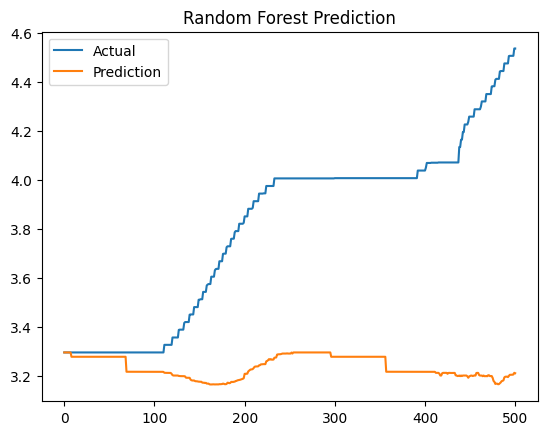

In [184]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Prediction')
plt.legend()
plt.title("Random Forest Prediction")
plt.show()

XGBoost

In [185]:
from xgboost import XGBRegressor

In [186]:
df = pd.read_csv("data.csv", sep=';')
# print("Data awal:")
# print(df.head())

In [187]:
df = df.iloc[1:]
df = df.reset_index(drop=True)

In [188]:
df.columns = [
    'time',
    'global_radiation',
    'temperature',
    'humidity',
    'irrigation',
    'irrigation_time',
    'rain_water',
    'drain'
]

In [189]:
df['time'] = pd.to_datetime(df['time'], dayfirst=True)

numeric_cols = [
    'global_radiation',
    'temperature',
    'humidity',
    'irrigation',
    'irrigation_time',
    'rain_water',
    'drain'
]

In [190]:
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df['irrigation_diff'] = df['irrigation'].diff()
# hapus missing value
df = df.dropna()

In [191]:
# 5. FEATURE ENGINEERING WAKTU
# =========================================================
df['hour'] = df['time'].dt.hour
df['day'] = df['time'].dt.day
df['month'] = df['time'].dt.month

# =========================================================
# 6. LAG FEATURE
# =========================================================
df['lag1'] = df['irrigation'].shift(1)
df['lag2'] = df['irrigation'].shift(2)
df['lag3'] = df['irrigation'].shift(3)
df['lag4'] = df['irrigation'].shift(4)
df['lag5'] = df['irrigation'].shift(5)
df['lag6'] = df['irrigation_diff'].shift(6)
df['lag7'] = df['irrigation_diff'].shift(7)
df['lag8'] = df['irrigation_diff'].shift(8)
# rolling mean untuk bantu baca pola lokal
df['rolling_mean_3'] = df['irrigation'].rolling(3).mean()
df['rolling_mean_5'] = df['irrigation'].rolling(5).mean()
df['rolling_mean_10'] = df['irrigation_diff'].rolling(10).mean()

df['rolling_std_5'] = df['irrigation_diff'].rolling(5).std()
# 🔥 perubahan cepat (momentum)
df['diff2'] = df['irrigation_diff'].diff(1)

# 🔥 max/min lokal
df['rolling_max_5'] = df['irrigation_diff'].rolling(5).max()
df['rolling_min_5'] = df['irrigation_diff'].rolling(5).min()

In [192]:
# hapus NaN akibat lag/rolling
df = df.dropna().reset_index(drop=True)

# =========================================================
# 7. PILIH FEATURE DAN TARGET
# =========================================================
X = df[
    [
        'global_radiation',
        'temperature',
        'humidity',
        'irrigation_time',
        'rain_water',
        'hour',
        'day',
        'month',
        'lag1',
        'lag2',
        'lag3',
        'lag4',
        'lag5',
        'lag6',
        'lag7',
        'lag8',
        'rolling_mean_3',
        'rolling_mean_5',
        'rolling_mean_10',
        'rolling_std_5',
        'rolling_max_5',
        'rolling_min_5',
        'diff2'
    ]
]

y = df['irrigation_diff']

print("\nUkuran data:")
print("X shape:", X.shape)
print("y shape:", y.shape)


Ukuran data:
X shape: (2498, 23)
y shape: (2498,)


In [193]:
# =========================================================
# 8. SPLIT DATA BERDASARKAN WAKTU (BUKAN RANDOM)
# =========================================================
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("\nData train:", X_train.shape, y_train.shape)
print("Data test :", X_test.shape, y_test.shape)


Data train: (1998, 23) (1998,)
Data test : (500, 23) (500,)


In [194]:
# =========================================================
# 9. MODEL XGBOOST
# =========================================================
model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=8,
    min_child_weight=3,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1,
    objective='reg:squarederror',
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=800,
             n_jobs=None, num_parallel_tree=None, ...)

In [195]:
# =========================================================
# 10. PREDIKSI
# =========================================================
y_pred = model.predict(X_test)


In [196]:
# =========================================================
# 11. EVALUASI
# =========================================================
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nHasil Evaluasi XGBoost")
print("MSE  :", mse)
print("RMSE :", rmse)
print("MAE  :", mae)
print("R2   :", r2)


Hasil Evaluasi XGBoost
MSE  : 2.42265252256759
RMSE : 1.5564872381640622
MAE  : 0.322790943088592
R2   : 0.9634887553566409


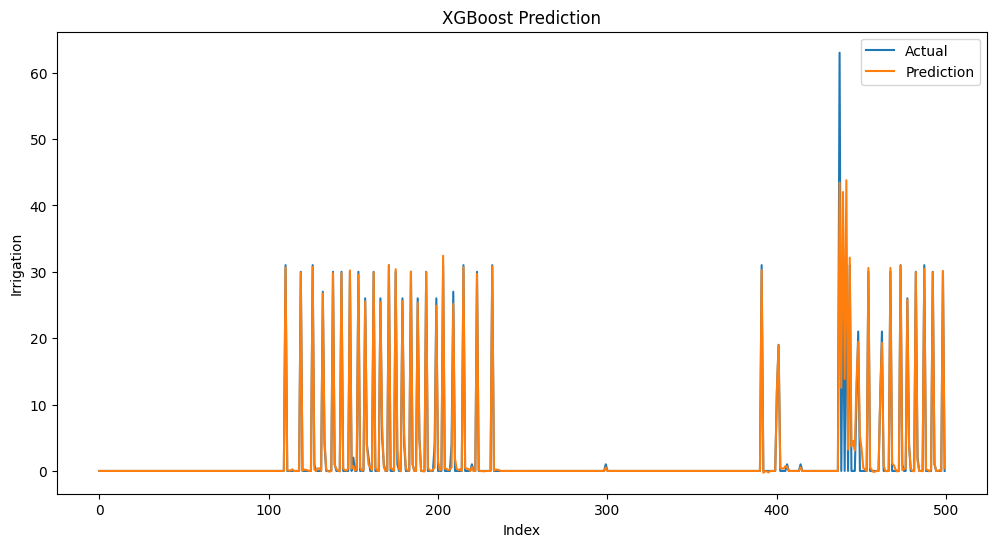

In [197]:
# =========================================================
# 12. VISUALISASI ACTUAL VS PREDICTION
# =========================================================
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Prediction')
plt.title("XGBoost Prediction")
plt.xlabel("Index")
plt.ylabel("Irrigation")
plt.legend()
plt.show()


Feature Importance:
             feature  importance
22             diff2    0.794538
20     rolling_max_5    0.071627
18   rolling_mean_10    0.015072
19     rolling_std_5    0.014885
2           humidity    0.013773
8               lag1    0.013666
13              lag6    0.012948
14              lag7    0.011779
0   global_radiation    0.010899
10              lag3    0.006867
1        temperature    0.005379
6                day    0.004996
12              lag5    0.004581
11              lag4    0.004241
3    irrigation_time    0.003567
15              lag8    0.003447
5               hour    0.003089
9               lag2    0.002015
16    rolling_mean_3    0.001466
4         rain_water    0.001163
7              month    0.000000
17    rolling_mean_5    0.000000
21     rolling_min_5    0.000000


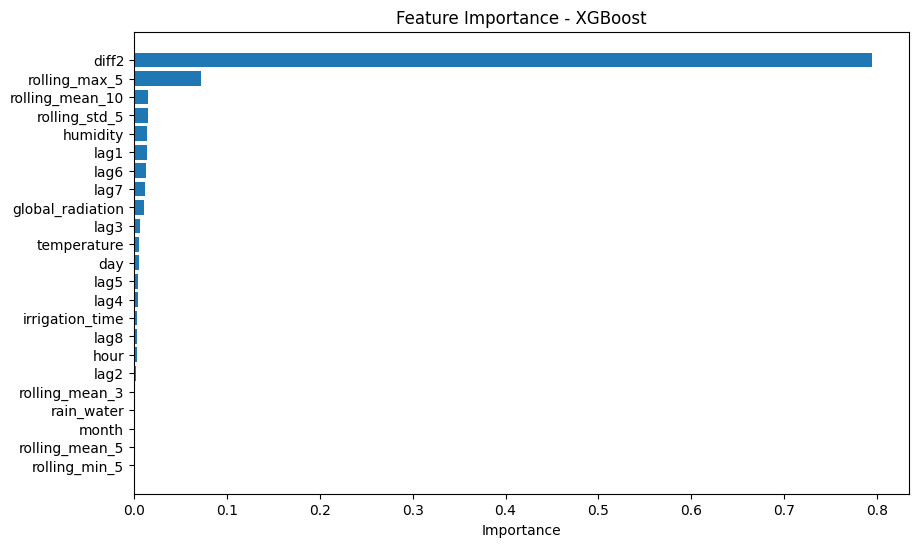

In [198]:
# =========================================================
# 13. FEATURE IMPORTANCE
# =========================================================
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nFeature Importance:")
print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance")
plt.show()

LSTM

In [215]:
df = pd.read_csv("data_clean.csv", sep=',')
print(df.head())

                  time  global_radiation  temperature  humidity  irrigation  \
0  2016-05-30 00:00:00                 0         19.4      91.4           0   
1  2016-05-30 00:05:00                 1         19.4      90.8           0   
2  2016-05-30 00:10:00                 0         19.3      91.3           0   
3  2016-05-30 00:15:00                 0         19.5      91.0           0   
4  2016-05-30 00:20:00                 0         19.5      91.0           0   

   irrigation_time  rain_water  drain  hour  day  month   Z-Score  
0             22.0           0      0     0   30      5  0.826460  
1             22.0           0      0     0   30      5  0.772896  
2             22.0           0      0     0   30      5  0.817533  
3             22.0           0      0     0   30      5  0.790751  
4             22.0           0      0     0   30      5  0.790751  


In [218]:

# # rename kolom
df.columns = ['time','global_radiation','temperature','humidity','irrigation','irrigation_time','rain_water','drain', 'hour','day', 'month','Z-Score']

# hapus baris unit
# df = df.iloc[1:]
# df = df.reset_index(drop=True)

# df.columns = [
#     'time',
#     'global_radiation',
#     'temperature',
#     'humidity',
#     'irrigation',
#     'irrigation_time',
#     'rain_water',
#     'drain'
# ]


In [220]:
# df['time'] = pd.to_datetime(df['time'], dayfirst=True)
numeric_cols = ['time','global_radiation','temperature','humidity','irrigation','irrigation_time','rain_water','drain', 'hour','day', 'month','Z-Score']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna().reset_index(drop=True)

In [ ]:
# df['hour'] = df['time'].dt.hour
# df['day'] = df['time'].dt.day
# df['month'] = df['time'].dt.month

In [221]:
features = [
    'time','global_radiation','temperature','humidity','irrigation','irrigation_time','rain_water','drain', 'hour','day', 'month','Z-Score'
]

data = df[features].copy()
print(data.head())

                  time  global_radiation  temperature  humidity  irrigation  \
0  1464566400000000000                 0         19.4      91.4           0   
1  1464566700000000000                 1         19.4      90.8           0   
2  1464567000000000000                 0         19.3      91.3           0   
3  1464567300000000000                 0         19.5      91.0           0   
4  1464567600000000000                 0         19.5      91.0           0   

   irrigation_time  rain_water  drain  hour  day  month   Z-Score  
0             22.0           0      0     0   30      5  0.826460  
1             22.0           0      0     0   30      5  0.772896  
2             22.0           0      0     0   30      5  0.817533  
3             22.0           0      0     0   30      5  0.790751  
4             22.0           0      0     0   30      5  0.790751  


In [222]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

print(scaled_data[:5])

[[0.00000000e+00 0.00000000e+00 7.43801653e-02 8.91802374e-01
  0.00000000e+00 4.78260870e-01 0.00000000e+00 0.00000000e+00
  0.00000000e+00 9.66666667e-01 0.00000000e+00 2.75912290e-01]
 [3.98883127e-04 1.12612613e-03 7.43801653e-02 8.78553685e-01
  0.00000000e+00 4.78260870e-01 0.00000000e+00 0.00000000e+00
  0.00000000e+00 9.66666667e-01 0.00000000e+00 2.57948218e-01]
 [7.97766254e-04 0.00000000e+00 6.61157025e-02 8.89594259e-01
  0.00000000e+00 4.78260870e-01 0.00000000e+00 0.00000000e+00
  0.00000000e+00 9.66666667e-01 0.00000000e+00 2.72918278e-01]
 [1.19664938e-03 0.00000000e+00 8.26446281e-02 8.82969914e-01
  0.00000000e+00 4.78260870e-01 0.00000000e+00 0.00000000e+00
  0.00000000e+00 9.66666667e-01 0.00000000e+00 2.63936242e-01]
 [1.59553251e-03 0.00000000e+00 8.26446281e-02 8.82969914e-01
  0.00000000e+00 4.78260870e-01 0.00000000e+00 0.00000000e+00
  0.00000000e+00 9.66666667e-01 0.00000000e+00 2.63936242e-01]]


In [223]:
def create_sequences(data, target_col_index, time_steps=10):
    X, y = [], []
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i])
        y.append(data[i, target_col_index])
    return np.array(X), np.array(y)

target_col_index = data.columns.get_loc('irrigation')
time_steps = 10

X, y = create_sequences(scaled_data, target_col_index, time_steps)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2480, 10, 12)
y shape: (2480,)


In [224]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1984, 10, 12)
X_test : (496, 10, 12)
y_train: (1984,)
y_test : (496,)


In [225]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),

    LSTM(32, return_sequences=False),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

model.summary()

C:\Users\jardm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 10, 64)         │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,673 (127.63 KB)

 Trainable params: 32,673 (127.63 KB)

 Non-trainable params: 0 (0.00 B)

In [226]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0102 - val_loss: 0.0099
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0026 - val_loss: 0.0190
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0018 - val_loss: 0.0202
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0016 - val_loss: 0.0297
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0013 - val_loss: 0.0257
Epoch 6/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0011 - val_loss: 0.0174
Epoch 7/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0010 - val_loss: 0.0260
Epoch 8/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.3982e-04 - val_loss: 0.0245
Epoch 9/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.9780e-04 - val_loss: 0.0188
Epoch 10/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.8446e-04 - val_loss: 0.0246
Epoch 11/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.0858e-04 - val_loss: 0.0228


In [227]:
y_pred = model.predict(X_test)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [228]:
# buat array dummy untuk inverse transform
dummy_pred = np.zeros((len(y_pred), scaled_data.shape[1]))
dummy_test = np.zeros((len(y_test), scaled_data.shape[1]))

# isi kolom target (irrigation)
dummy_pred[:, target_col_index] = y_pred.flatten()
dummy_test[:, target_col_index] = y_test.flatten()

# inverse transform
y_pred_inv = scaler.inverse_transform(dummy_pred)[:, target_col_index]
y_test_inv = scaler.inverse_transform(dummy_test)[:, target_col_index]

In [229]:
mse = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)

print("Hasil Evaluasi LSTM")
print("MSE  :", mse)
print("RMSE :", rmse)
print("MAE  :", mae)
print("R2   :", r2)

Hasil Evaluasi LSTM
MSE  : 203510.55236500996
RMSE : 451.121438600528
MAE  : 434.6265848428011
R2   : -0.557865564387038


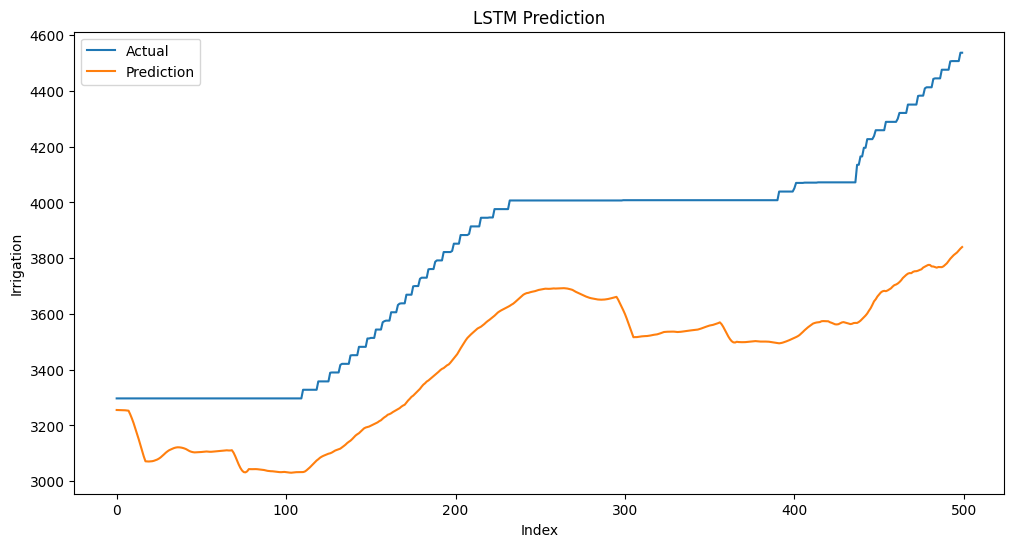

In [212]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_inv, label='Prediction')
plt.title("LSTM Prediction")
plt.xlabel("Index")
plt.ylabel("Irrigation")
plt.legend()
plt.show()

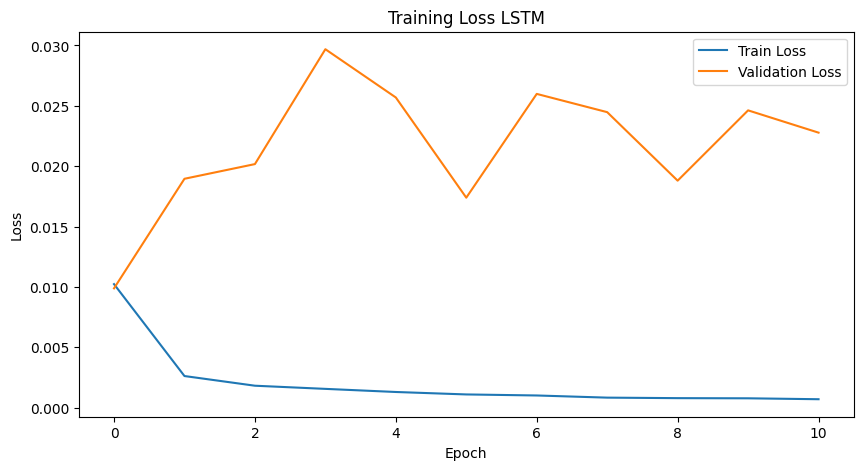

In [230]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training Loss LSTM")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()